In [ ]:
import json
import os
import base64
import numpy as np
from PIL import Image
import io
import tensorflow as tf
from tensorflow.keras.metrics import Precision, Recall

In [ ]:
KEY_MAPPING = {"w": 0,
               "s": 1,
               "a": 2,
               "d": 3,
               "wd": 4, "dw": 4,
               "wa": 5, "aw": 5,
               "sd": 6, "ds": 6, 
               "sa": 7, "as": 7
}

IS_SIMPLE = True

## Utility

In [55]:
def get_json_files(dataset_path):
    """
    Returns list of all JSON files in the dataset directory and its subdirectories
    Args:
        dataset_path (str): Path to dataset directory
    Returns:
        list: List of JSON file paths
    """
    try:
        json_files = []
        # Walk through all directories and subdirectories
        for root, dirs, files in os.walk(dataset_path):
            # Filter for JSON files
            for file in files:
                if file.endswith('.json'):
                    full_path = os.path.join(root, file)
                    json_files.append(full_path)
        
        # Sort files for consistent ordering
        json_files.sort()        
        return json_files
        
    except Exception as e:
        print(f"[Error] Failed to scan dataset directory: {e}")
        return []

In [3]:
def base64_to_image(base64_string, target_size=(224, 224)):
    """
    Converts base64 string to PIL Image and resizes to target dimensions
    Args:
        base64_string (str): Base64 encoded image string
        target_size (tuple): Target dimensions (width, height)
    Returns:
        PIL.Image: Decoded and resized image
    """
    try:
        # Remove header if present
        if ',' in base64_string:
            base64_string = base64_string.split(',')[1]
        
        # Decode base64 to bytes
        img_bytes = base64.b64decode(base64_string)
        
        # Convert bytes to PIL Image
        img = Image.open(io.BytesIO(img_bytes))
        
        # Convert to RGB if image is in different mode (e.g., RGBA)
        if img.mode != 'RGB':
            img = img.convert('RGB')
        
        # Resize image to target size
        img = img.resize(target_size, Image.Resampling.BILINEAR)
        
        return img
        
    except Exception as e:
        print(f"[Error] Failed to convert base64 to image: {e}")
        return None

In [108]:
def get_training_data(json_file_path, image_size=(224, 224)):
    """
    Extracts training data (images and labels) from telemetry JSON file
    Args:
        json_file_path (str): Path to telemetry JSON file
        image_size (tuple): Target image dimensions (width, height)
    Returns:
        tuple: (X, y) where X is list of images and y is list of actions
    """
    try:
            # Read telemetry data
        with open(json_file_path, 'r') as f:
            telemetry_data = json.load(f)
        
        # Validate required fields
        required_fields = ['completed', 'totalTime', 'actions']
        if not all(field in telemetry_data for field in required_fields):
            raise ValueError('Invalid telemetry data format')
        
    except Exception as e:
        print(f"[Error] Error: {e}")
        return None, None
        

    # Initialize lists for images and labels
    X = []  # Images
    y = []  # Actions/Labels

    try:
        # Process each action in telemetry
        for action in telemetry_data['actions']:
            if 'screenshotBase64' in action:
                # Convert base64 to image
                img = base64_to_image(action['screenshotBase64'], image_size)
                if img:
                    # Convert PIL image to numpy array
                    img_array = np.array(img)
                    X.append(img_array)
                    
                    # Extract action/label (you'll need to modify this based on your action format)
                    y_temp = action.get('keypressInputs', [])
                    if IS_SIMPLE:
                        y_temp = y_temp[-2:]
                    else:
                        y_temp = y_temp[-1]
                    y_temp = "".join(y_temp).replace("Arrow", "").replace("Shift", "")
                    y_temp = y_temp.replace("Up", "w").replace("Down", "s").replace("Left", "a").replace("Right", "d")
                    y_temp = y_temp.replace("sw", "w")
                    y_temp = y_temp.replace("ws", "s")
                    y_temp = y_temp.replace("ad", "d")
                    y_temp = y_temp.replace("da", "a")
                    if len(y_temp) != 0:
                        y.append(KEY_MAPPING[y_temp]) 
                    else:
                        y.append(0)
        
        # Convert lists to numpy arrays
        X, y = np.array(X)/255.0, np.array(y)
        return X.mean(axis=-1), y.reshape(-1, 1)

    except Exception as e:
        print(f"[Error] Failed to extract training data: {e}")
        return None, None

In [113]:
def create_tf_dataset(X, Y, batch_size=32, shuffle=True, shuffle_buffer=1000):
    """
    Creates a TensorFlow Dataset for training/evaluation
    Args:
        X (np.ndarray): Input features/images
        Y (np.ndarray): Labels/actions
        batch_size (int): Size of each batch
        shuffle (bool): Whether to shuffle the data
        shuffle_buffer (int): Size of the shuffle buffer
    Returns:
        tf.data.Dataset: TensorFlow dataset object
    """
    # Convert inputs to float32 if they aren't already
    X = tf.cast(X, tf.float32)
    Y = tf.cast(Y, tf.float32)
    
    # Create dataset from tensors
    dataset = tf.data.Dataset.from_tensor_slices((X, Y))
    
    # Add channel dimension if needed
    if len(X.shape) == 3:  # (samples, height, width)
        dataset = dataset.map(
            lambda x, y: (tf.expand_dims(x, axis=-1), y),
            num_parallel_calls=tf.data.AUTOTUNE
        )
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=shuffle_buffer)
    
    # Batch the data
    dataset = dataset.batch(batch_size)
    
    # Prefetch for better performance
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset


In [114]:
def train_val_split(X, Y, val_size=0.2, random_seed=42):
    """
    Splits data into training and validation sets
    Args:
        X (np.ndarray): Input features
        Y (np.ndarray): Labels
        val_size (float): Fraction of data to use for validation (0 to 1)
        random_seed (int): Random seed for reproducibility
    Returns:
        tuple: (X_train, X_val, y_train, y_val)
    """
    # Set random seed
    np.random.seed(random_seed)
    
    # Get total number of samples
    n_samples = len(X)
    
    # Create shuffled indices
    indices = np.random.permutation(n_samples)
    
    # Calculate split point
    val_samples = int(n_samples * val_size)
    
    # Split indices
    train_indices = indices[val_samples:]
    val_indices = indices[:val_samples]
    
    # Split data
    X_train, X_val = X[train_indices], X[val_indices]
    y_train, y_val = Y[train_indices], Y[val_indices]
    
    return X_train, X_val, y_train, y_val

In [ ]:
# Create a custom F1 Score metric
class F1Score(tf.keras.metrics.Metric):
    def __init__(self, name='f1_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.precision = Precision()
        self.recall = Recall()
        
    def update_state(self, y_true, y_pred, sample_weight=None):
        # Convert probabilities to class predictions
        y_pred = tf.argmax(y_pred, axis=1)
        y_true = tf.cast(y_true, tf.int64)
        
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)
    
    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * ((p * r) / (p + r + tf.keras.backend.epsilon()))
    
    def reset_state(self):
        self.precision.reset_state()
        self.recall.reset_state()

## Data

In [ ]:

# Read Data From JSON Files
res = get_json_files("./Dataset")

X, Y = [], []
for data in res:
    x, y = get_training_data(data)
    X.append(x)
    Y.append(y)
X = np.concatenate(X, axis=0)
Y = np.concatenate(Y, axis=0)

In [115]:
# Split the data
X_train, X_val, y_train, y_val = train_val_split(X, Y, val_size=0.2)

# Create train and validation datasets
batch_size = 32
train_dataset = create_tf_dataset(X_train, y_train, batch_size=batch_size, shuffle=True)
val_dataset = create_tf_dataset(X_val, y_val, batch_size=batch_size, shuffle=False)

# Print shapes to verify split
print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")

2025-03-11 13:39:19.417264: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2025-03-11 13:39:19.417407: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2025-03-11 13:39:19.417440: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.00 GB
2025-03-11 13:39:19.417583: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-03-11 13:39:19.417644: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Training samples: 8743
Validation samples: 2185


## Model

In [148]:
def create_cnn_model(input_dims, output_dim):
    """
    Creates a simple CNN model using TensorFlow layers
    Returns:
        tf.keras.Model: Compiled CNN model
    """
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), activation=tf.nn.relu, padding='same', input_shape=input_dims),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
        tf.keras.layers.BatchNormalization(),
        
        tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), activation=tf.nn.relu, padding='same'),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
        tf.keras.layers.BatchNormalization(),
        
        tf.keras.layers.Conv2D(filters=128, kernel_size=(3, 3), activation=tf.nn.relu, padding='same'),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
        tf.keras.layers.BatchNormalization(),

        tf.keras.layers.Conv2D(filters=256, kernel_size=(3, 3), activation=tf.nn.relu, padding='same'),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
        tf.keras.layers.BatchNormalization(),
        
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(units=256, activation=tf.nn.relu),
        tf.keras.layers.Dense(units=128, activation=tf.nn.relu),
        tf.keras.layers.Dense(units=output_dim, activation=tf.nn.softmax)
    ])
    
    model.compile(optimizer=tf.optimizers.Adam(learning_rate=0.001), loss=tf.losses.SparseCategoricalCrossentropy(), metrics=['accuracy', F1Score()])
    
    return model

In [149]:
model = create_cnn_model((224, 224, 1), 4 if IS_SIMPLE else 8)
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_34 (Conv2D)              │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,268,484 (50.62 MB)

 Trainable params: 13,267,524 (50.61 MB)

 Non-trainable params: 960 (3.75 KB)

## Training


In [150]:
# Training parameters
epochs = 5
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_f1_score', mode='max', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(train_dataset, epochs=epochs, validation_data=val_dataset, callbacks=[early_stopping])

# Print final metrics
final_train_loss, final_train_acc, final_train_f1 = history.history['loss'][-1], history.history['accuracy'][-1], history.history['f1_score'][-1]
final_val_loss, final_val_acc, final_val_f1 = history.history['val_loss'][-1], history.history['val_accuracy'][-1], history.history['val_f1_score'][-1]

Epoch 1/5


: 

In [ ]:
print(f"\nFinal Training Metrics:\nLoss: {final_train_loss:.4f}\nAccuracy: {final_train_acc:.4f}\nF1 Score: {final_train_f1:.4f}")
print(f"\nFinal Validation Metrics:\nLoss: {final_val_loss:.4f}\nAccuracy: {final_val_acc:.4f}\nF1 Score: {final_val_f1:.4f}")

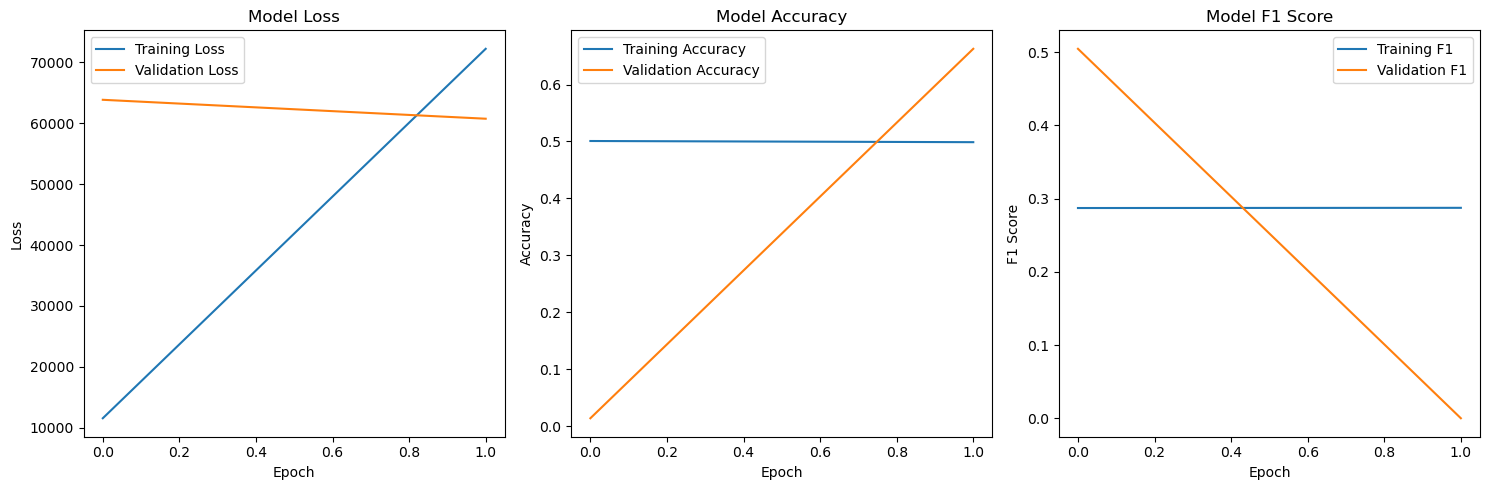

In [126]:
# Plot training history
plt.figure(figsize=(15, 5))

# Plot loss
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot F1 Score
plt.subplot(1, 3, 3)
plt.plot(history.history['f1_score'], label='Training F1')
plt.plot(history.history['val_f1_score'], label='Validation F1')
plt.title('Model F1 Score')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Save the best model
model.save('./models/my_model.keras')